In [ ]:
!pip install ISLP

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 522.0/522.0 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 815.2/815.2 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 926.4/926.4 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.5/94.5 kB 4.8 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4031 sha256=d59f883bd2454a7bb7dfd720ca704717443d806e29ed219615cacaeae8dc2fc0
  Stored in directory: /root/.cache/pip/wheels/25/cc/e0/ef2969164144c899fedb22b338f6703e2b9cf46eeebf254991
Successfully built autograd-gamma
  Attempting uni

In [ ]:
from sklearn.svm import SVC
from ISLP.svm import plot as plot_svm
from sklearn.metrics import RocCurveDisplay

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split,GridSearchCV
from matplotlib.pyplot import subplots , cm
import sklearn.model_selection as skm
from ISLP import load_data , confusion_table

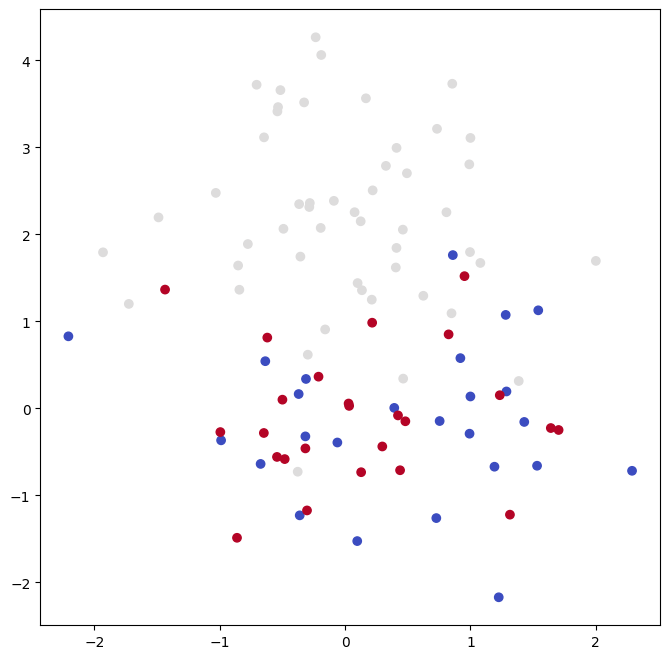

In [ ]:
rng = np.random.default_rng (123)
X = rng.standard_normal((50, 2))
y = np.array([-1]*25+[1]*25)
X = np.vstack([X, rng.standard_normal((50, 2))])
y = np.hstack([y, [0]*50])
X[y==0,1] += 2
fig , ax = subplots(figsize=(8,8))
ax.scatter(X[:,0], X[:,1], c=y, cmap=cm.coolwarm)

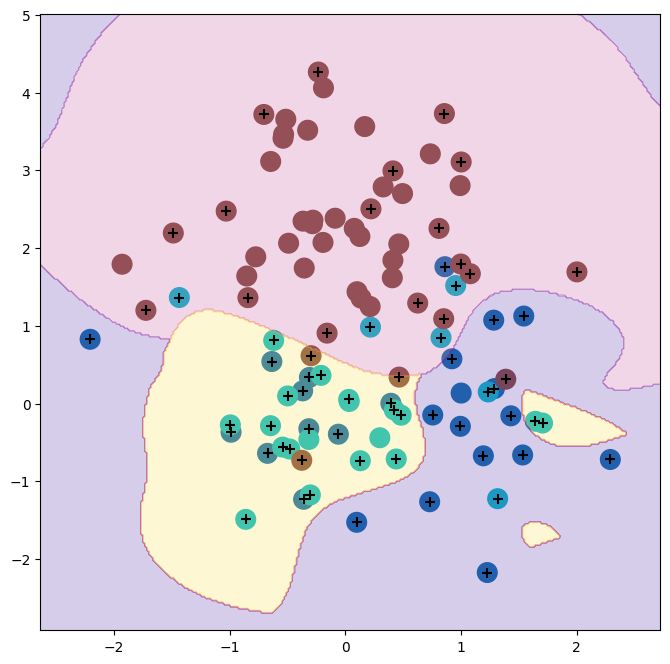

In [ ]:
###one vs one####
svm_rbf_3 = SVC(kernel="rbf",C=10, gamma=1, decision_function_shape='ovo')
svm_rbf_3.fit(X, y)
fig, ax = subplots(figsize=(8,8))
plot_svm(X,y,svm_rbf_3,scatter_cmap=cm.tab10,ax=ax)

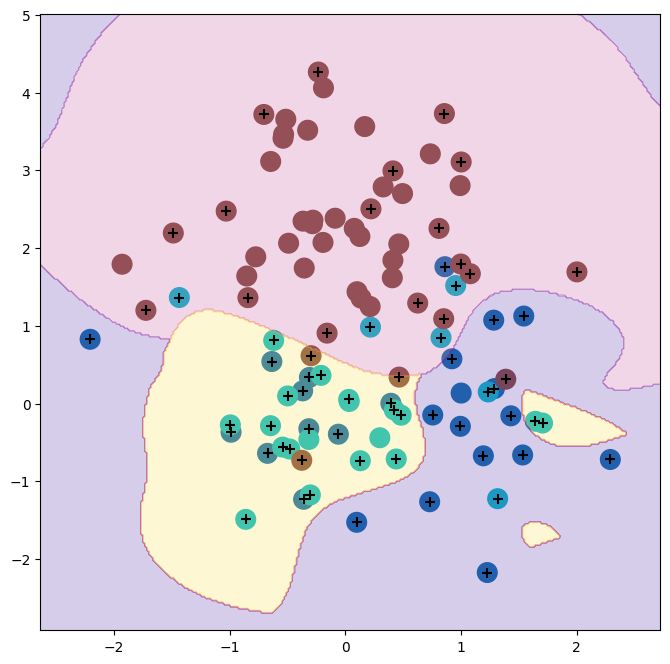

In [ ]:
###one vs all##
svm_rbf_4 = SVC(kernel="rbf",C=10, gamma=1, decision_function_shape='ovr')
svm_rbf_4.fit(X, y)
fig, ax = subplots(figsize=(8,8))
plot_svm(X,y,svm_rbf_4,scatter_cmap=cm.tab10,ax=ax)

In [ ]:
####Gene Expression Data###
Khan = load_data('Khan')
Khan['xtrain'].shape , Khan['xtest'].shape

((63, 2308), (20, 2308))

In [ ]:
khan_ovo = SVC(kernel="linear",C=10, gamma=1, decision_function_shape='ovr')
khan_ovo.fit(Khan['xtrain'], Khan['ytrain'])
confusion_table(khan_ovo.predict(Khan['xtrain']), Khan['ytrain'])

Truth,1,2,3,4
Predicted,,,,
1,8,0,0,0
2,0,23,0,0
3,0,0,12,0
4,0,0,0,20


In [ ]:
confusion_table(khan_ovo.predict(Khan['xtest']), Khan['ytest'])

Truth,1,2,3,4
Predicted,,,,
1,3,0,0,0
2,0,6,2,0
3,0,0,4,0
4,0,0,0,5


In [ ]:
# Import necessary libraries
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error
import pandas as pd


In [ ]:
# Load the Boston dataset
boston = load_data("Boston")

# Prepare features and target
X_boston = boston.drop(columns='medv')
y_boston = boston['medv']

# Train-Test split using train_test_split
X_train_boston, X_test_boston, y_train_boston, y_test_boston = train_test_split(
    X_boston, y_boston, test_size=0.5, random_state=8)

In [ ]:
svr_rbf = SVR(kernel='rbf', C=2, gamma=1)

# Fit the model on the training data
svr_rbf.fit(X_train_boston, y_train_boston)

# Make predictions on the test set
y_pred_test = svr_rbf.predict(X_test_boston)

# Evaluate the model performance
mse = mean_squared_error(y_test_boston, y_pred_test)


print(f"Test Set MSE of the SVR Model with RBF Kernel: {mse:.4f}")

In [ ]:
# Define the SVR model as the initial model for GridSearchCV
svr_model = SVR()

# Set up parameter grid to search over multiple kernels and other hyperparameters
param_grid = {
    'kernel': ['rbf', 'linear', 'poly', 'sigmoid'],  # Kernel types
    'C': [0.1, 5],  # Cost parameter
    'gamma': [0.1,  5],  # Kernel coefficient
    'degree': [2,  4]  # Degree of the polynomial kernel, only relevant for 'poly'
}

# Set up cross-validation
kfold = KFold(n_splits=5, random_state=0, shuffle=True)
# Define GridSearchCV
grid_search = GridSearchCV(estimator=svr_model,
                           param_grid=param_grid,
                           refit=True,
                           cv=kfold,
                           scoring='neg_mean_squared_error')  # Use neg MSE as the scoring

# Fit GridSearchCV on the training data
grid_search.fit(X_train_boston, y_train_boston)
print("Mean Test Scores for Each Parameter Combination (neg MSE):")
print(grid_search.cv_results_['mean_test_score'])
print("\nBest Parameters:", grid_search.best_params_)

In [ ]:
# Get the best SVR model from GridSearchCV
best_svr = grid_search.best_estimator_

# Make predictions on the test set with the best model
y_pred_test = best_svr.predict(X_test_boston)

# Evaluate the model performance
mse = mean_squared_error(y_test_boston, y_pred_test)
print(f"\nTest Set MSE of the Best SVR Model: {mse:.4f}")